In [24]:
import nibabel as nib
import numpy as np
from nilearn import datasets, plotting, surface
from scipy.spatial import cKDTree 

def remove_medial_wall(vertices, faces, medialWallMask):
    new_vertices = vertices[medialWallMask]
    #Create a mapping from old vertex indices to new indices
    index_mapping = np.where(medialWallMask)[0]  # Gets the new indices of the original vertices
    
    # Identify faces to remove
    # Convert mask to apply to faces
    faces_mask = np.all(medialWallMask[faces], axis=1)  # Checks if all vertices of a face are kept
    remaining_faces = faces[faces_mask]  # Keep only faces where all vertices are kept
    
    # Adjust indices in remaining faces to match filtered vertices
    # Create an inverse mapping for the vertices that are kept
    inverse_mapping = np.zeros_like(medialWallMask, dtype=int)
    inverse_mapping[index_mapping] = np.arange(len(index_mapping))
    
    # Update the faces to new indices
    new_faces = inverse_mapping[remaining_faces]
    
    return new_vertices, new_faces

In [45]:
gradient_file_path = 'hcp.embed.all.179.lh.dscalar.nii'
surf_file_path_32k = 'Q1-Q6_R440.L.midthickness.32k_fs_LR.surf.gii'
target_mesh_file = 'tpl-fsaverage_den-10k_hemi-L_pial.surf.gii'
medialwall_file = 'fsaverage5_medial_wall_lh_masked.txt'

In [46]:
gii_img = nib.load(surf_file_path_32k)
# The first data array in a Gifti surface file typically contains the vertex coordinates.
# We get the number of vertices directly from the shape of this data array.
expected_vertices = gii_img.darrays[0].data.shape[0]
source_mesh_vertices = gii_img.darrays[0].data
source_mesh_faces = gii_img.darrays[1].data
# nilearn's plot_surf_stat_map can often directly use the path to a .gii file as surf_mesh.
surf_mesh_to_plot = surf_file_path_32k
img = nib.load(gradient_file_path)
# Get the data as a numpy array and flatten it.
# We assume the NIfTI file contains a 1D array of values that can be
# flattened to match the number of vertices.
stat_map_data = img.get_fdata().flatten()

print(f"NIfTI data length: {len(stat_map_data)}, vertices for the loaded surface: {expected_vertices}")


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


NIfTI data length: 32492, vertices for the loaded surface: 32492


In [47]:
max_abs_val = np.max(np.abs(stat_map_data))
vmax_val = max_abs_val
vmin_val = -max_abs_val

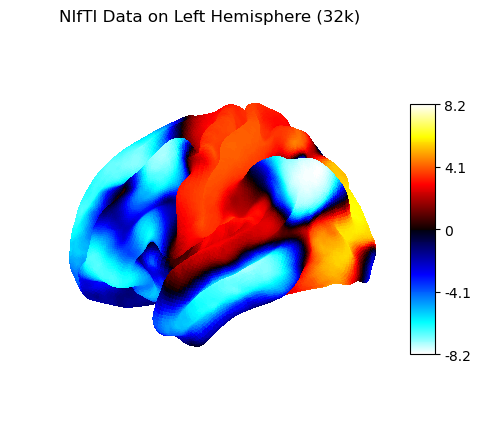

In [48]:
fig = plotting.plot_surf_stat_map(
        surf_mesh=surf_mesh_to_plot,
        stat_map=stat_map_data,
        # bg_map=sulc_left, # Removed as a corresponding 32k sulcal map is not provided.
        # If you have a 32k sulcal map (.gii or FreeSurfer format) that matches
        # your 32k surface, you can load it and pass it here.
        hemi='left',
        view='lateral', # You can change this to 'medial', 'anterior', 'posterior', 'superior', 'inferior'
        colorbar=True, # Display a colorbar
        title=f'NIfTI Data on Left Hemisphere (32k)',
        cmap='cold_hot', # Choose a colormap, e.g., 'cold_hot', 'viridis', 'magma', 'jet'
        vmax=vmax_val, # Max value for colorbar scaling
        vmin=vmin_val # Min value for colorbar scaling
    )

In [49]:
# load txt with labeling (0 or 1) for medial wall vertices
medialWallMask = []
with open(medialwall_file, 'r') as file:
    for line in file:
        medialWallMask.append(int(line.strip()))
medialWallMask = np.array(medialWallMask, dtype=bool)

gii_data = nib.load(target_mesh_file)
faces = gii_data.darrays[1].data
vertices = gii_data.darrays[0].data

[target_mesh_vertices, target_mesh_faces] = remove_medial_wall(vertices, faces, medialWallMask)

In [50]:
source_mesh = (source_mesh_vertices, source_mesh_faces)
target_mesh = (target_mesh_vertices, target_mesh_faces)

In [51]:
# Create a KD-tree from the source mesh vertices
# This allows for efficient nearest neighbor queries
source_kdtree = cKDTree(source_mesh_vertices)

# Query the KD-tree with the target mesh vertices
# For each vertex in the target mesh, find its nearest neighbor in the source mesh.
# 'distances' are the distances to the nearest neighbors (not used for resampling data values)
# 'indices' are the indices of the nearest neighbors in the source_mesh_vertices array
distances, indices = source_kdtree.query(target_mesh_vertices)

# Use these indices to map the stat_map_data from the source to the target
resampled_stat_map_data = stat_map_data[indices]

In [52]:
output_filename = 'resampled_principal_gradient.csv'

# Save the array to a CSV file
# fmt='%f' ensures float formatting
# delimiter=',' sets comma as the separator
np.savetxt(output_filename, resampled_stat_map_data, fmt='%f', delimiter=',')

print(f"Rescaled data saved to '{output_filename}' successfully.")

Rescaled data saved to 'resampled_principal_gradient.csv' successfully.


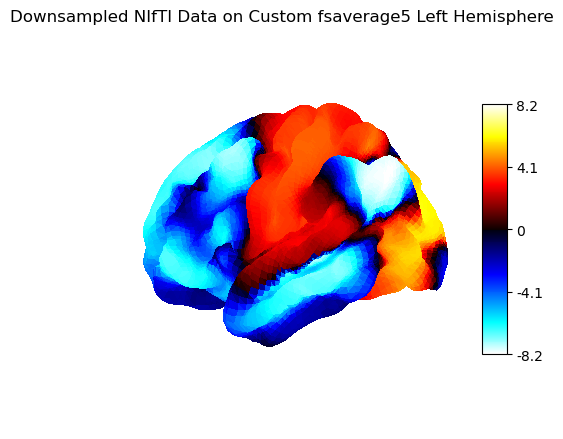

In [53]:
# Calculate the absolute maximum value for symmetric colormap scaling
max_abs_val = np.max(np.abs(resampled_stat_map_data))
vmax_val = max_abs_val
vmin_val = -max_abs_val

fig = plotting.plot_surf_stat_map(
    surf_mesh=(target_mesh_vertices, target_mesh_faces), # Use the loaded vertices and faces
    stat_map=resampled_stat_map_data,
    hemi='left',
    view='lateral',
    colorbar=True,
    title='Downsampled NIfTI Data on Custom fsaverage5 Left Hemisphere',
    cmap='cold_hot',
    vmax=vmax_val,
    vmin=vmin_val
)